In [48]:
 # 1. Setup & Imports

In [49]:
import subprocess
subprocess.run(["pip", "install", "pandas", "numpy", "matplotlib", "seaborn", "scikit-learn", "scipy", "yellowbrick"])

CompletedProcess(args=['pip', 'install', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'scipy', 'yellowbrick'], returncode=0)

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('darkgrid')
print("All imports successful!")

All imports successful!


In [51]:
# CELL 3 — Load the dataset
df = pd.read_csv('marketing_campaign.csv', sep='\t')
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
df.head()

Shape: (2240, 29)

Column names:
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [52]:
#CELL 4 — Check missing values and data types
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\n=== BASIC STATS ===")
print(df.describe().round(2))

=== DATA TYPES ===
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

=== MISSING VALUES ===
Income    24
dtype: int64

=== BASIC STATS =

In [53]:
#CELL 5 — Check categorical columns for problems
print("Education unique values:")
print(df['Education'].value_counts())

print("\nMarital Status unique values:")
print(df['Marital_Status'].value_counts())

print("\nAge range check (2024 - Year_Birth):")
ages = 2024 - df['Year_Birth']
print("Min age:", ages.min())
print("Max age:", ages.max())
print("Ages above 90:", (ages > 90).sum())

print("\nIncome top 5 values:")
print(df['Income'].sort_values(ascending=False).head())

Education unique values:
Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

Marital Status unique values:
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

Age range check (2024 - Year_Birth):
Min age: 28
Max age: 131
Ages above 90: 3

Income top 5 values:
2233    666666.0
617     162397.0
687     160803.0
1300    157733.0
164     157243.0
Name: Income, dtype: float64


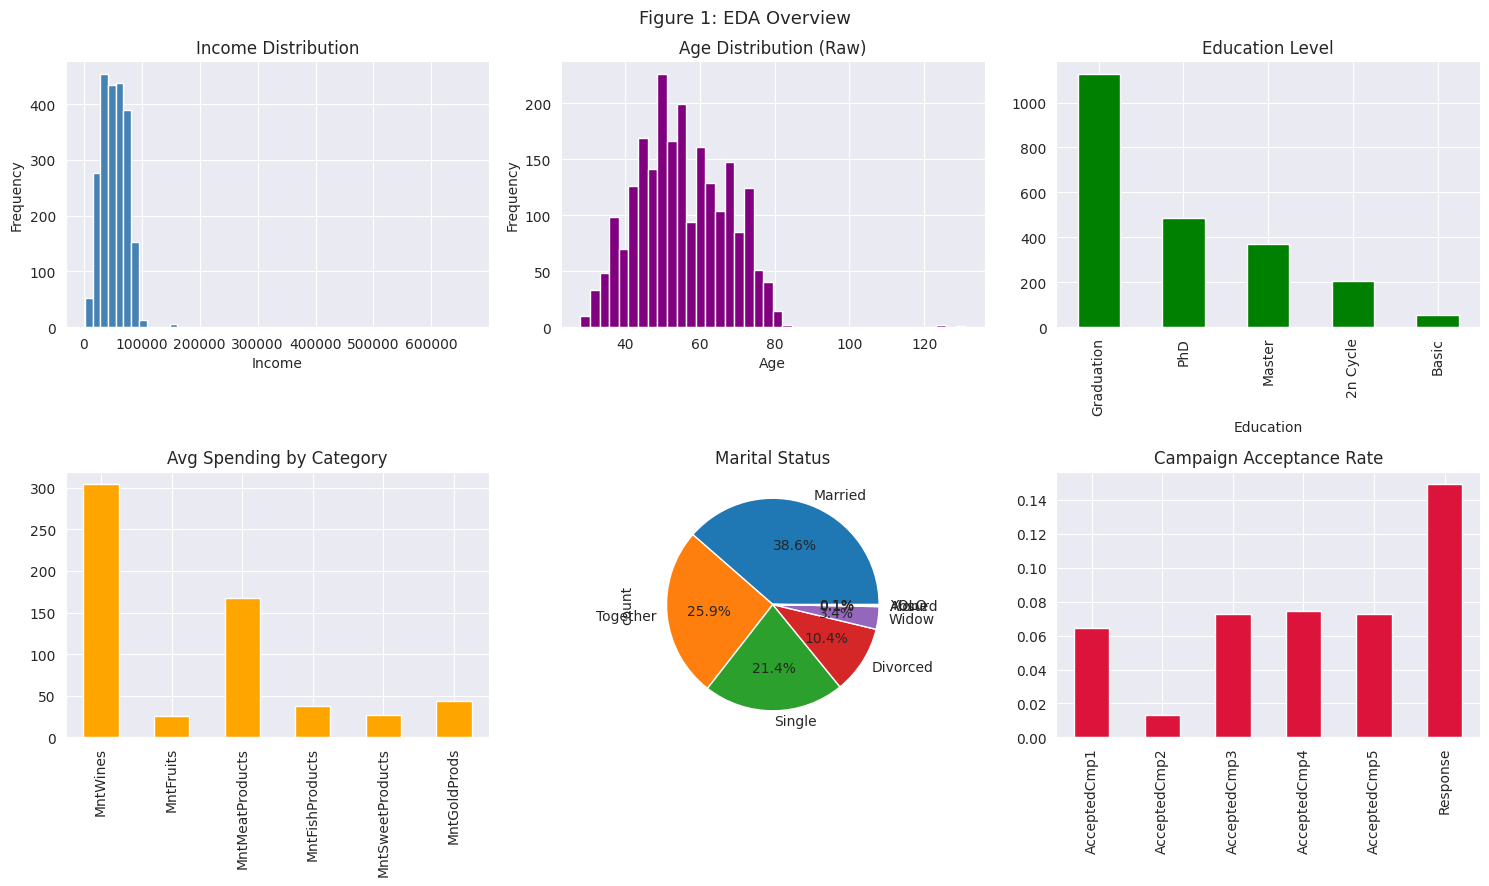

Saved: fig1_eda_distributions.png


In [54]:
#CELL 6 — EDA plots (saves as fig1)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

df['Income'].plot(kind='hist', bins=50, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Income Distribution')
axes[0,0].set_xlabel('Income')

(2024 - df['Year_Birth']).plot(kind='hist', bins=40, ax=axes[0,1], color='purple')
axes[0,1].set_title('Age Distribution (Raw)')
axes[0,1].set_xlabel('Age')

df['Education'].value_counts().plot(kind='bar', ax=axes[0,2], color='green')
axes[0,2].set_title('Education Level')

spend_cols = ['MntWines','MntFruits','MntMeatProducts',
              'MntFishProducts','MntSweetProducts','MntGoldProds']
df[spend_cols].mean().plot(kind='bar', ax=axes[1,0], color='orange')
axes[1,0].set_title('Avg Spending by Category')

df['Marital_Status'].value_counts().plot(kind='pie', ax=axes[1,1], autopct='%1.1f%%')
axes[1,1].set_title('Marital Status')

df[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5','Response']].mean().plot(kind='bar', ax=axes[1,2], color='crimson')
axes[1,2].set_title('Campaign Acceptance Rate')

plt.suptitle('Figure 1: EDA Overview', fontsize=13)
plt.tight_layout()
plt.savefig('fig1_eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig1_eda_distributions.png")

In [55]:
#CELL 7 — Data cleaning
print("=== BEFORE CLEANING ===")
print("Rows:", len(df))
print("Missing Income:", df['Income'].isnull().sum())

# Fix 1: Fill missing Income with median
median_income = df['Income'].median()
df['Income'].fillna(median_income, inplace=True)
print(f"\nFilled 24 missing incomes with median: ${median_income:,.0f}")

# Fix 2: Remove impossible ages (over 90)
old_len = len(df)
df = df[(2024 - df['Year_Birth']) <= 90]
print(f"Removed {old_len - len(df)} rows where age > 90")

# Fix 3: Fix garbage marital status values
df['Marital_Status'] = df['Marital_Status'].replace({'Alone': 'Single'})
old_len = len(df)
df = df[~df['Marital_Status'].isin(['YOLO', 'Absurd'])]
print(f"Removed {old_len - len(df)} garbage marital status rows")

# Fix 4: Remove extreme income outlier ($666,666)
old_len = len(df)
df = df[df['Income'] < 200000]
df = df.reset_index(drop=True)
print(f"Removed {old_len - len(df)} extreme income outliers")

print("\n=== AFTER CLEANING ===")
print("Rows:", len(df))
print("Missing values:", df.isnull().sum().sum())

=== BEFORE CLEANING ===
Rows: 2240
Missing Income: 24

Filled 24 missing incomes with median: $51,382
Removed 3 rows where age > 90
Removed 4 garbage marital status rows
Removed 1 extreme income outliers

=== AFTER CLEANING ===
Rows: 2232
Missing values: 0


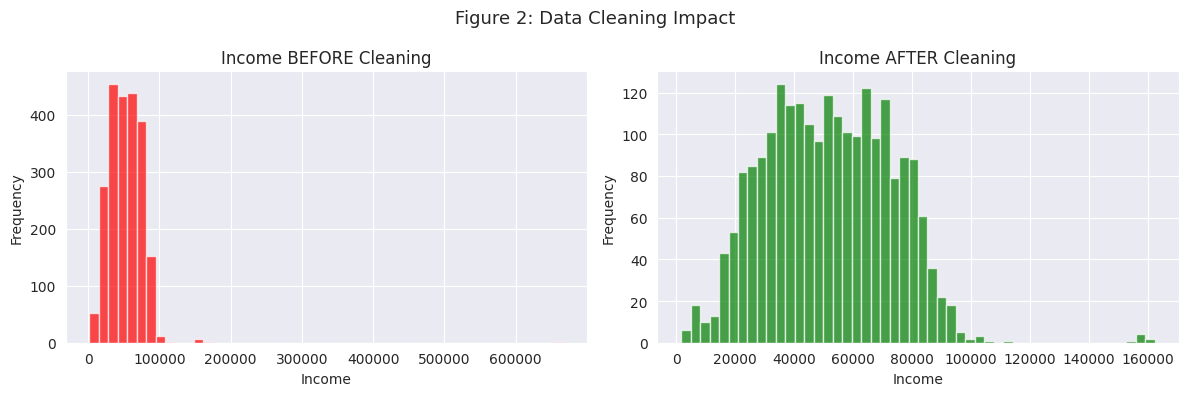

Saved: fig2_cleaning.png


In [56]:
#CELL 8 — Before/after cleaning plot (saves as fig2)
df_raw = pd.read_csv('marketing_campaign.csv', sep='\t')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_raw['Income'].plot(kind='hist', bins=50, ax=axes[0], color='red', alpha=0.7)
axes[0].set_title('Income BEFORE Cleaning')
axes[0].set_xlabel('Income')

df['Income'].plot(kind='hist', bins=50, ax=axes[1], color='green', alpha=0.7)
axes[1].set_title('Income AFTER Cleaning')
axes[1].set_xlabel('Income')

plt.suptitle('Figure 2: Data Cleaning Impact', fontsize=13)
plt.tight_layout()
plt.savefig('fig2_cleaning.png', dpi=150)
plt.show()
print("Saved: fig2_cleaning.png")

In [57]:
# CELL 9 — Feature engineering
# 1. Age
df['Age'] = 2024 - df['Year_Birth']

# 2. Total spending across all 6 product categories
spend_cols = ['MntWines','MntFruits','MntMeatProducts',
              'MntFishProducts','MntSweetProducts','MntGoldProds']
df['Total_Spending'] = df[spend_cols].sum(axis=1)

# 3. Total children at home
df['NumChildren'] = df['Kidhome'] + df['Teenhome']

# 4. Is the customer a parent?
df['Is_Parent'] = (df['NumChildren'] > 0).astype(int)

# 5. How long have they been a customer (in days)
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
df['Customer_Tenure'] = (pd.Timestamp('2024-01-01') - df['Dt_Customer']).dt.days

# 6. Total campaigns accepted
cmp_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']
df['Total_Campaigns'] = df[cmp_cols].sum(axis=1)

# 7. Education as ordered number
edu_map = {'Basic': 0, '2n Cycle': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}
df['Education_Num'] = df['Education'].map(edu_map)

print("New features created successfully!")
new_features = ['Age','Total_Spending','NumChildren','Is_Parent',
                'Customer_Tenure','Total_Campaigns','Education_Num']
print(df[new_features].describe().round(1))

New features created successfully!
          Age  Total_Spending  NumChildren  Is_Parent  Customer_Tenure  \
count  2232.0          2232.0       2232.0     2232.0           2232.0   
mean     55.1           605.6          1.0        0.7           3826.5   
std      11.7           602.1          0.8        0.5            202.1   
min      28.0             5.0          0.0        0.0           3473.0   
25%      47.0            69.0          0.0        0.0           3653.8   
50%      54.0           396.0          1.0        1.0           3828.5   
75%      65.0          1044.2          1.0        1.0           4001.2   
max      84.0          2525.0          3.0        1.0           4172.0   

       Total_Campaigns  Education_Num  
count           2232.0         2232.0  
mean               0.3            2.5  
std                0.7            1.0  
min                0.0            0.0  
25%                0.0            2.0  
50%                0.0            2.0  
75%               

Feature matrix shape: (2232, 11)


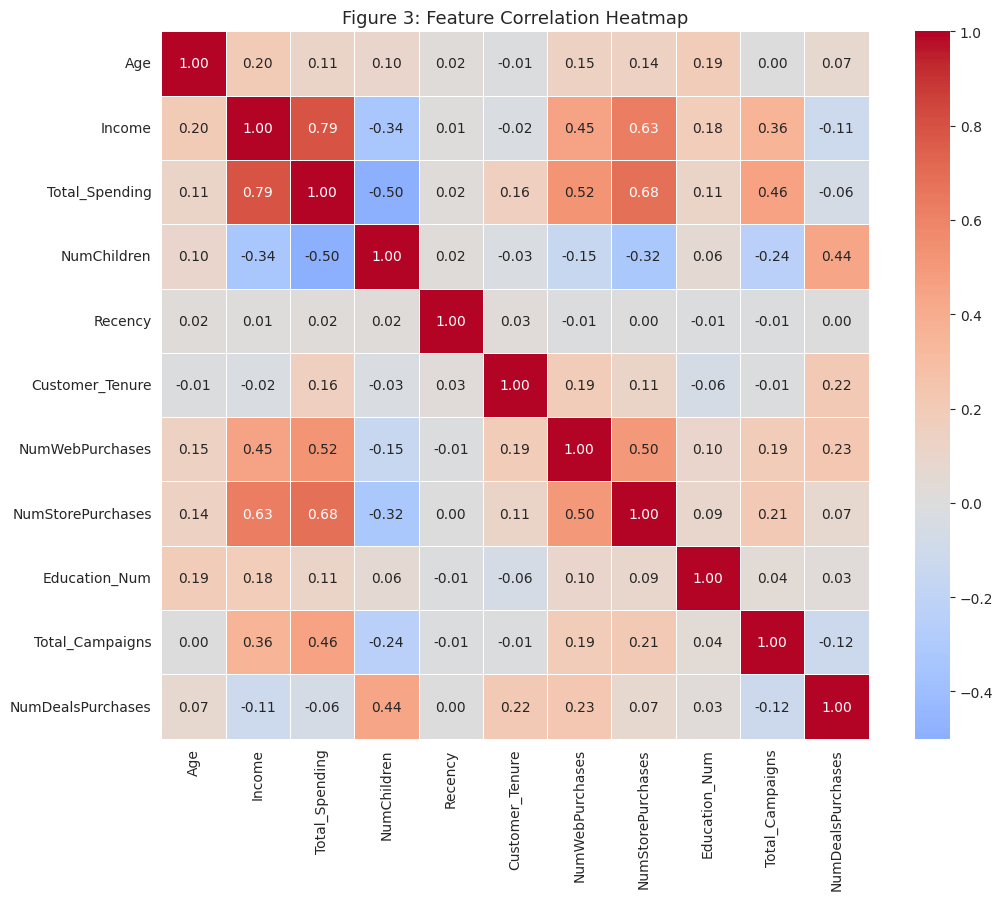

Saved: fig3_correlation_heatmap.png


In [58]:
#CELL 10 — Correlation heatmap (saves as fig3)
features = ['Age', 'Income', 'Total_Spending', 'NumChildren',
            'Recency', 'Customer_Tenure', 'NumWebPurchases',
            'NumStorePurchases', 'Education_Num',
            'Total_Campaigns', 'NumDealsPurchases']

X = df[features].dropna()
print("Feature matrix shape:", X.shape)

plt.figure(figsize=(11, 9))
corr = X.corr().round(2)
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', linewidths=0.5)
plt.title('Figure 3: Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.savefig('fig3_correlation_heatmap.png', dpi=150)
plt.show()
print("Saved: fig3_correlation_heatmap.png")

In [59]:
# CELL 11 — Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling — Income:")
print(f"  Mean: ${X['Income'].mean():,.0f}, Std: ${X['Income'].std():,.0f}")

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print("\nAfter scaling — Income:")
print(f"  Mean: {X_scaled_df['Income'].mean():.4f}, Std: {X_scaled_df['Income'].std():.4f}")
print("\nScaling complete! All features now have mean=0 and std=1")

Before scaling — Income:
  Mean: $51,937, Std: $21,421

After scaling — Income:
  Mean: 0.0000, Std: 1.0002

Scaling complete! All features now have mean=0 and std=1


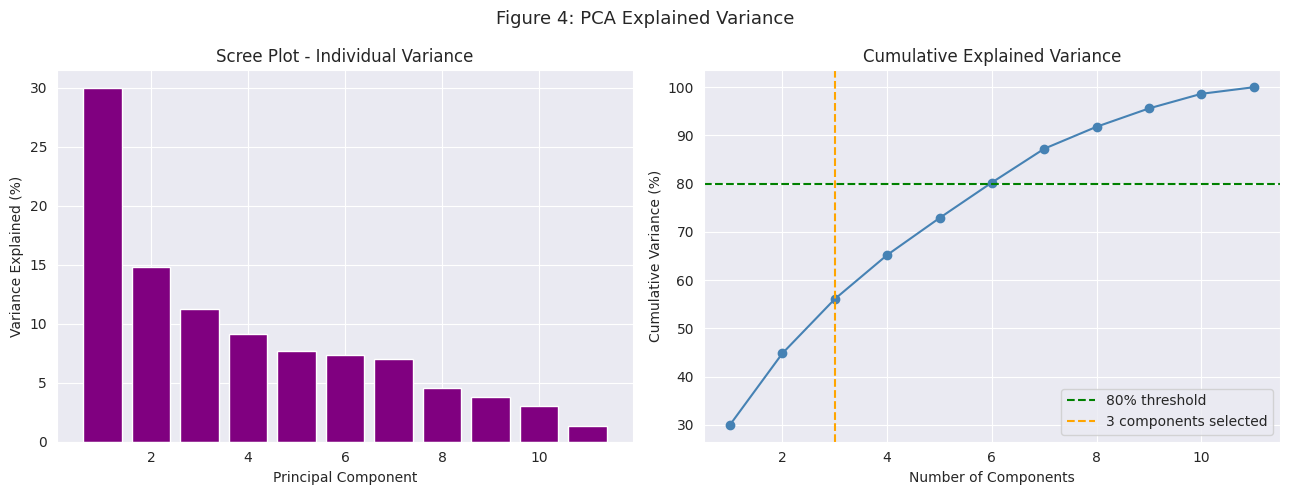

Variance explained per component:
  PC1: 29.98%
  PC2: 14.82%
  PC3: 11.27%
  PC4: 9.14%
  PC5: 7.67%
  PC6: 7.37%
  PC7: 7.01%
  PC8: 4.56%
  PC9: 3.80%
  PC10: 3.03%
  PC11: 1.37%

Saved: fig4_pca_variance.png


In [60]:
# CELL 12 — PCA analysis (saves as fig4)
# Run PCA on all components first to see variance
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Individual variance per component
axes[0].bar(range(1, 12), pca_full.explained_variance_ratio_ * 100, color='purple')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot - Individual Variance')

# Cumulative variance
cum_var = np.cumsum(pca_full.explained_variance_ratio_) * 100
axes[1].plot(range(1, 12), cum_var, marker='o', color='steelblue')
axes[1].axhline(80, linestyle='--', color='green', label='80% threshold')
axes[1].axvline(3, linestyle='--', color='orange', label='3 components selected')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.suptitle('Figure 4: PCA Explained Variance', fontsize=13)
plt.tight_layout()
plt.savefig('fig4_pca_variance.png', dpi=150)
plt.show()

print("Variance explained per component:")
for i, v in enumerate(pca_full.explained_variance_ratio_, 1):
    print(f"  PC{i}: {v*100:.2f}%")
print(f"\nSaved: fig4_pca_variance.png")

In [61]:
# CELL 13 — Apply PCA with 3 components
# 3 components for clustering
pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled)

# 2 components for visualization
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

print("3-component PCA total variance:", round(pca3.explained_variance_ratio_.sum() * 100, 2), "%")
print("Shape of X_pca3:", X_pca3.shape)

# Show what each component represents
print("\n=== PCA Component Loadings (what each PC means) ===")
components_df = pd.DataFrame(
    pca3.components_.T,
    index=features,
    columns=['PC1', 'PC2', 'PC3']
).round(3)
print(components_df)

3-component PCA total variance: 56.06 %
Shape of X_pca3: (2232, 3)

=== PCA Component Loadings (what each PC means) ===
                     PC1    PC2    PC3
Age                0.112  0.288  0.499
Income             0.472 -0.016  0.153
Total_Spending     0.509 -0.029 -0.071
NumChildren       -0.297  0.466  0.160
Recency            0.002  0.031 -0.035
Customer_Tenure    0.075  0.297 -0.553
NumWebPurchases    0.359  0.326 -0.124
NumStorePurchases  0.437  0.126 -0.056
Education_Num      0.097  0.185  0.584
Total_Campaigns    0.281 -0.190  0.007
NumDealsPurchases -0.047  0.646 -0.173


K=2 done — Inertia: 8030.0, Silhouette: 0.3818
K=3 done — Inertia: 6040.9, Silhouette: 0.3556
K=4 done — Inertia: 5002.1, Silhouette: 0.3046
K=5 done — Inertia: 4369.1, Silhouette: 0.2731
K=6 done — Inertia: 3905.1, Silhouette: 0.2768
K=7 done — Inertia: 3575.5, Silhouette: 0.2775
K=8 done — Inertia: 3302.3, Silhouette: 0.2735
K=9 done — Inertia: 3037.6, Silhouette: 0.2556
K=10 done — Inertia: 2841.3, Silhouette: 0.2555


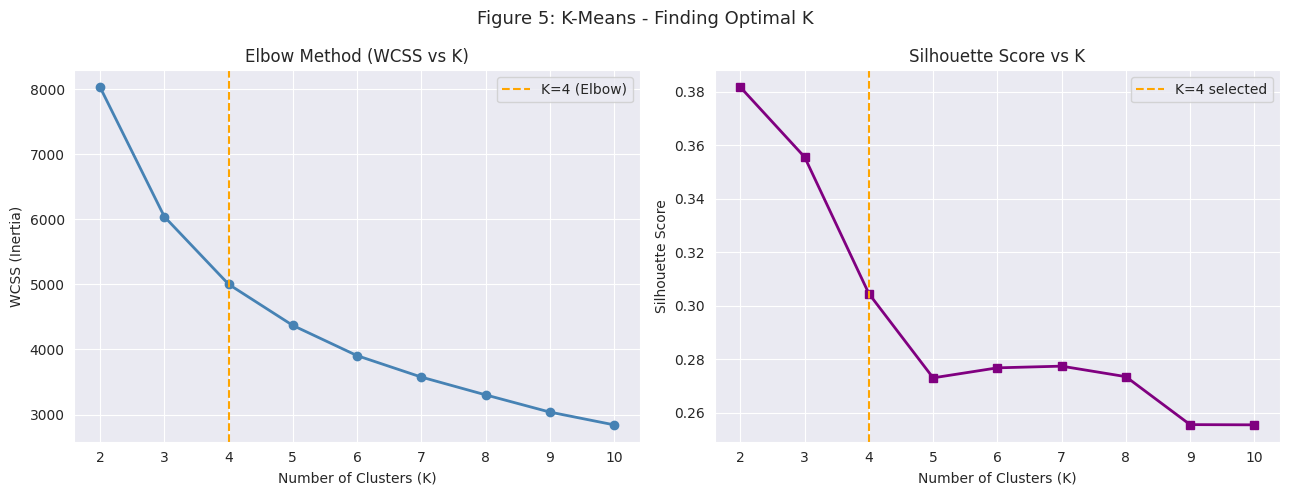

Saved: fig5_kmeans_elbow.png


In [62]:
# CELL 14 — K-Means elbow method (saves as fig5)
inertias = []
silhouette_scores_km = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca3)
    inertias.append(km.inertia_)
    silhouette_scores_km.append(silhouette_score(X_pca3, labels))
    print(f"K={k} done — Inertia: {km.inertia_:.1f}, Silhouette: {silhouette_score(X_pca3, labels):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(K_range), inertias, 'o-', color='steelblue', linewidth=2)
axes[0].axvline(4, color='orange', linestyle='--', label='K=4 (Elbow)')
axes[0].set_title('Elbow Method (WCSS vs K)')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].legend()

axes[1].plot(list(K_range), silhouette_scores_km, 's-', color='purple', linewidth=2)
axes[1].axvline(4, color='orange', linestyle='--', label='K=4 selected')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.suptitle('Figure 5: K-Means - Finding Optimal K', fontsize=13)
plt.tight_layout()
plt.savefig('fig5_kmeans_elbow.png', dpi=150)
plt.show()
print("Saved: fig5_kmeans_elbow.png")

In [63]:
# CELL 15 — Final K-Means with K=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
km_labels = km_final.fit_predict(X_pca3)

df_model = df.loc[X.index].copy()
df_model['KMeans_Cluster'] = km_labels
df_model['PC1'] = X_pca2[:, 0]
df_model['PC2'] = X_pca2[:, 1]

km_sil = silhouette_score(X_pca3, km_labels)
km_db  = davies_bouldin_score(X_pca3, km_labels)
km_ch  = calinski_harabasz_score(X_pca3, km_labels)

print("=== K-Means K=4 Results ===")
print(f"Silhouette Score:      {km_sil:.4f}  (higher is better)")
print(f"Davies-Bouldin Index:  {km_db:.4f}   (lower is better)")
print(f"Calinski-Harabasz:     {km_ch:.1f} (higher is better)")
print("\nCluster sizes:")
print(df_model['KMeans_Cluster'].value_counts().sort_index())

=== K-Means K=4 Results ===
Silhouette Score:      0.3046  (higher is better)
Davies-Bouldin Index:  1.1352   (lower is better)
Calinski-Harabasz:     1301.0 (higher is better)

Cluster sizes:
KMeans_Cluster
0    551
1    537
2    524
3    620
Name: count, dtype: int64


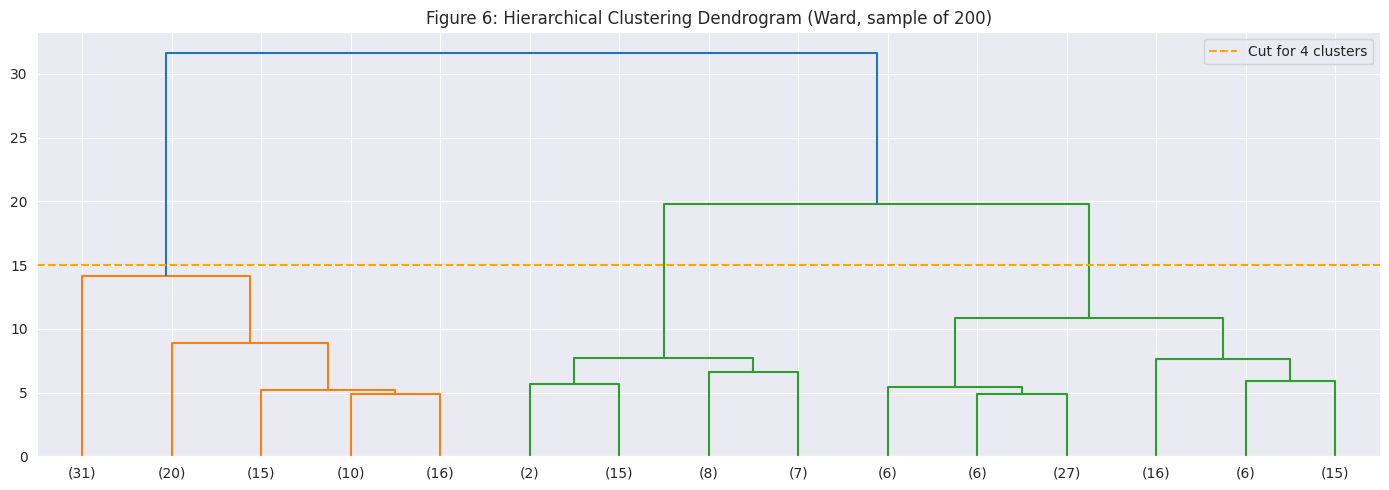

Saved: fig6_dendrogram.png

=== Agglomerative Clustering Results ===
Linkage=ward     | Silhouette=0.2707 | DB=1.1921 | CH=1103.1
Linkage=complete | Silhouette=0.1952 | DB=1.2580 | CH=595.3
Linkage=average  | Silhouette=0.3550 | DB=0.7950 | CH=592.8

Agglomerative (ward) cluster sizes:
Agg_Cluster
0    688
1    447
2    501
3    596
Name: count, dtype: int64


In [64]:
# CELL 16 — Agglomerative clustering (saves as fig6
# Dendrogram on a sample of 200 rows
X_sample = X_pca3[:200]
Z = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=15, leaf_font_size=10)
plt.axhline(15, color='orange', linestyle='--', label='Cut for 4 clusters')
plt.title('Figure 6: Hierarchical Clustering Dendrogram (Ward, sample of 200)')
plt.legend()
plt.tight_layout()
plt.savefig('fig6_dendrogram.png', dpi=150)
plt.show()
print("Saved: fig6_dendrogram.png")

# Try 3 linkage methods
print("\n=== Agglomerative Clustering Results ===")
for linkage_method in ['ward', 'complete', 'average']:
    agg = AgglomerativeClustering(n_clusters=4, linkage=linkage_method)
    labels = agg.fit_predict(X_pca3)
    sil = silhouette_score(X_pca3, labels)
    db  = davies_bouldin_score(X_pca3, labels)
    ch  = calinski_harabasz_score(X_pca3, labels)
    print(f"Linkage={linkage_method:8s} | Silhouette={sil:.4f} | DB={db:.4f} | CH={ch:.1f}")

# Save best (ward) labels
agg_best = AgglomerativeClustering(n_clusters=4, linkage='ward')
df_model['Agg_Cluster'] = agg_best.fit_predict(X_pca3)
print("\nAgglomerative (ward) cluster sizes:")
print(pd.Series(df_model['Agg_Cluster']).value_counts().sort_index())

In [65]:
# CELL 17 — Gaussian Mixture Model
print("=== Gaussian Mixture Model Results ===")
for cov_type in ['full', 'tied', 'diag']:
    gmm = GaussianMixture(n_components=4, covariance_type=cov_type, random_state=42)
    labels = gmm.fit_predict(X_pca3)
    sil = silhouette_score(X_pca3, labels)
    db  = davies_bouldin_score(X_pca3, labels)
    ch  = calinski_harabasz_score(X_pca3, labels)
    bic = gmm.bic(X_pca3)
    aic = gmm.aic(X_pca3)
    print(f"Covariance={cov_type:6s} | Silhouette={sil:.4f} | DB={db:.4f} | CH={ch:.1f} | BIC={bic:.0f} | AIC={aic:.0f}")

# Save best (full) labels
gmm_best = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
df_model['GMM_Cluster'] = gmm_best.fit_predict(X_pca3)
print("\nGMM (full) cluster sizes:")
print(pd.Series(df_model['GMM_Cluster']).value_counts().sort_index())

=== Gaussian Mixture Model Results ===
Covariance=full   | Silhouette=0.2543 | DB=1.2915 | CH=1098.6 | BIC=21908 | AIC=21685
Covariance=tied   | Silhouette=0.3010 | DB=1.1491 | CH=1286.4 | BIC=22425 | AIC=22305
Covariance=diag   | Silhouette=0.2730 | DB=1.1670 | CH=1167.5 | BIC=21938 | AIC=21784

GMM (full) cluster sizes:
GMM_Cluster
0    521
1    628
2    430
3    653
Name: count, dtype: int64


In [66]:
# CELL 18 — DBSCAN
print("=== DBSCAN Results ===")
print(f"{'eps':>6} | {'min_samples':>11} | {'n_clusters':>10} | {'n_noise':>7} | {'silhouette':>10}")
print("-" * 55)

for eps in [0.3, 0.5, 0.8, 1.0, 1.5]:
    for min_s in [5, 10, 15]:
        dbs = DBSCAN(eps=eps, min_samples=min_s)
        labels = dbs.fit_predict(X_pca3)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        if n_clusters >= 2:
            sil = round(silhouette_score(X_pca3, labels), 4)
        else:
            sil = 'N/A'
        print(f"{eps:>6} | {min_s:>11} | {n_clusters:>10} | {n_noise:>7} | {str(sil):>10}")

print("\nConclusion: DBSCAN struggles with this dataset.")
print("Customer data has continuous distributions — no clear density gaps.")
print("This justifies K-Means as the best choice.")

=== DBSCAN Results ===
   eps | min_samples | n_clusters | n_noise | silhouette
-------------------------------------------------------
   0.3 |           5 |         54 |    1048 |    -0.3502
   0.3 |          10 |         16 |    1745 |    -0.4513
   0.3 |          15 |          4 |    2018 |     -0.146
   0.5 |           5 |          6 |     180 |    -0.1545
   0.5 |          10 |          4 |     444 |    -0.1033
   0.5 |          15 |          1 |     760 |        N/A
   0.8 |           5 |          1 |      39 |        N/A
   0.8 |          10 |          1 |      63 |        N/A
   0.8 |          15 |          1 |      93 |        N/A
   1.0 |           5 |          1 |      16 |        N/A
   1.0 |          10 |          1 |      26 |        N/A
   1.0 |          15 |          1 |      34 |        N/A
   1.5 |           5 |          1 |       1 |        N/A
   1.5 |          10 |          1 |       2 |        N/A
   1.5 |          15 |          1 |       5 |        N/A

Conclusi

In [67]:
# CELL 19 — Full model comparison table (saves CSV + fig7)
comparison_results = []

# K-Means: K = 2, 3, 4, 5, 6
for k in [2, 3, 4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lb = km.fit_predict(X_pca3)
    comparison_results.append({
        'Model': f'KMeans_K{k}',
        'Algorithm': 'K-Means',
        'N_Clusters': k,
        'Silhouette': round(silhouette_score(X_pca3, lb), 4),
        'Davies_Bouldin': round(davies_bouldin_score(X_pca3, lb), 4),
        'Calinski_Harabasz': round(calinski_harabasz_score(X_pca3, lb), 1)
    })

# Agglomerative: 3 linkages
for lnk in ['ward', 'complete', 'average']:
    agg = AgglomerativeClustering(n_clusters=4, linkage=lnk)
    lb = agg.fit_predict(X_pca3)
    comparison_results.append({
        'Model': f'Agglomerative_{lnk}',
        'Algorithm': 'Hierarchical',
        'N_Clusters': 4,
        'Silhouette': round(silhouette_score(X_pca3, lb), 4),
        'Davies_Bouldin': round(davies_bouldin_score(X_pca3, lb), 4),
        'Calinski_Harabasz': round(calinski_harabasz_score(X_pca3, lb), 1)
    })

# GMM: 3 covariance types
for cov in ['full', 'tied', 'diag']:
    gmm = GaussianMixture(n_components=4, covariance_type=cov, random_state=42)
    lb = gmm.fit_predict(X_pca3)
    comparison_results.append({
        'Model': f'GMM_{cov}',
        'Algorithm': 'GMM',
        'N_Clusters': 4,
        'Silhouette': round(silhouette_score(X_pca3, lb), 4),
        'Davies_Bouldin': round(davies_bouldin_score(X_pca3, lb), 4),
        'Calinski_Harabasz': round(calinski_harabasz_score(X_pca3, lb), 1)
    })

results_df = pd.DataFrame(comparison_results)
results_df.to_csv('model_comparison_results.csv', index=False)

print("=== FULL MODEL COMPARISON TABLE ===")
print(results_df.to_string(index=False))
print("\nSaved: model_comparison_results.csv")

=== FULL MODEL COMPARISON TABLE ===
                 Model    Algorithm  N_Clusters  Silhouette  Davies_Bouldin  Calinski_Harabasz
             KMeans_K2      K-Means           2      0.3818          1.0798             1592.5
             KMeans_K3      K-Means           3      0.3556          1.0948             1424.9
             KMeans_K4      K-Means           4      0.3046          1.1352             1301.0
             KMeans_K5      K-Means           5      0.2731          1.2255             1197.2
             KMeans_K6      K-Means           6      0.2768          1.1748             1124.0
    Agglomerative_ward Hierarchical           4      0.2707          1.1921             1103.1
Agglomerative_complete Hierarchical           4      0.1952          1.2580              595.3
 Agglomerative_average Hierarchical           4      0.3550          0.7950              592.8
              GMM_full          GMM           4      0.2543          1.2915             1098.6
              

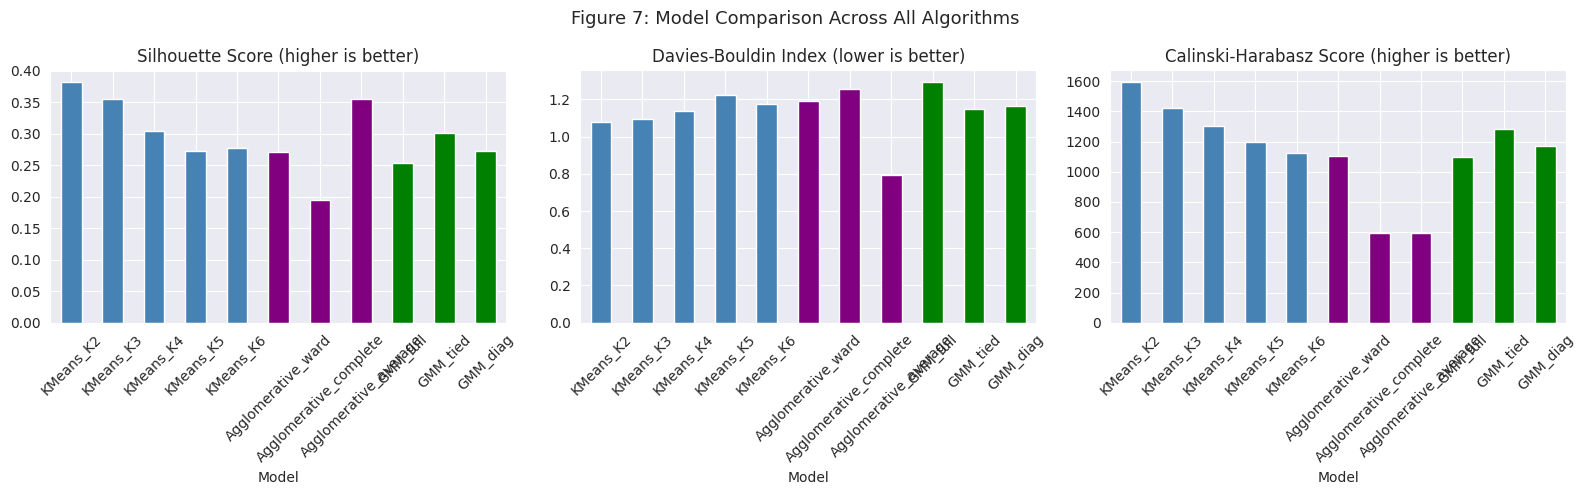

Saved: fig7_model_comparison.png


In [68]:
# CELL 20 — Model comparison bar chart (saves as fig7)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['steelblue' if 'KMeans' in m else 'purple' if 'Agg' in m else 'green'
          for m in results_df['Model']]

results_df.plot(x='Model', y='Silhouette', kind='bar',
                ax=axes[0], color=colors, legend=False)
axes[0].set_title('Silhouette Score (higher is better)')
axes[0].tick_params(axis='x', rotation=45)

results_df.plot(x='Model', y='Davies_Bouldin', kind='bar',
                ax=axes[1], color=colors, legend=False)
axes[1].set_title('Davies-Bouldin Index (lower is better)')
axes[1].tick_params(axis='x', rotation=45)

results_df.plot(x='Model', y='Calinski_Harabasz', kind='bar',
                ax=axes[2], color=colors, legend=False)
axes[2].set_title('Calinski-Harabasz Score (higher is better)')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Figure 7: Model Comparison Across All Algorithms', fontsize=13)
plt.tight_layout()
plt.savefig('fig7_model_comparison.png', dpi=150)
plt.show()
print("Saved: fig7_model_comparison.png")

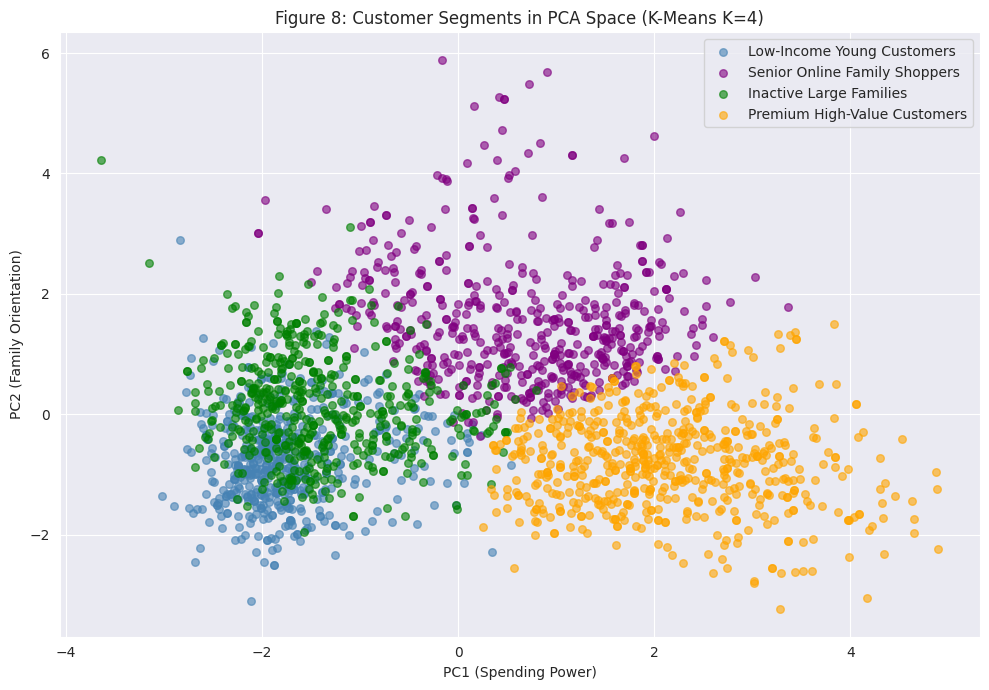

Saved: fig8_cluster_scatter.png


In [69]:
# CELL 21 — Cluster scatter plot (corrected names)

correct_names = {
    0: 'Low-Income Young Customers',
    1: 'Senior Online Family Shoppers',
    2: 'Inactive Large Families',
    3: 'Premium High-Value Customers'
}

colors_map = {0: 'steelblue', 1: 'purple', 2: 'green', 3: 'orange'}

plt.figure(figsize=(10, 7))
for cluster, color in colors_map.items():
    mask = df_model['KMeans_Cluster'] == cluster
    plt.scatter(df_model.loc[mask, 'PC1'],
                df_model.loc[mask, 'PC2'],
                c=color, label=correct_names[cluster], alpha=0.6, s=30)

plt.xlabel('PC1 (Spending Power)')
plt.ylabel('PC2 (Family Orientation)')
plt.title('Figure 8: Customer Segments in PCA Space (K-Means K=4)')
plt.legend()
plt.tight_layout()
plt.savefig('fig8_cluster_scatter.png', dpi=150)
plt.show()
print("Saved: fig8_cluster_scatter.png")

=== RAW CLUSTER PROFILES ===
                                Age   Income  Total_Spending  NumChildren  \
Low-Income Young Customers     46.4  30115.8           102.2          0.9   
Senior Online Family Shoppers  58.9  57156.8           758.2          1.3   
Inactive Large Families        59.6  41869.3           129.6          1.5   
Premium High-Value Customers   55.8  75319.2          1323.1          0.2   

                               Recency  Total_Campaigns  NumDealsPurchases  \
Low-Income Young Customers        48.5              0.1                1.8   
Senior Online Family Shoppers     49.4              0.2                4.4   
Inactive Large Families           50.1              0.1                2.2   
Premium High-Value Customers      48.7              0.8                1.2   

                               NumWebPurchases  
Low-Income Young Customers                 2.0  
Senior Online Family Shoppers              6.6  
Inactive Large Families                    2.3 

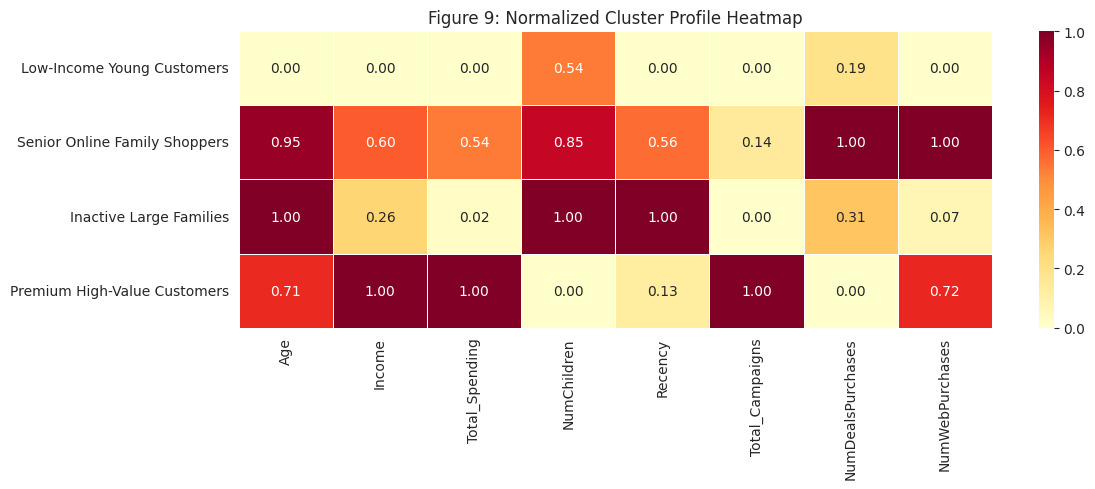

Saved: fig9_cluster_heatmap.png


In [70]:
# CELL 22 — Cluster profile heatmap (corrected names)

profile_cols = ['Age', 'Income', 'Total_Spending', 'NumChildren',
                'Recency', 'Total_Campaigns', 'NumDealsPurchases', 'NumWebPurchases']

profile_df = df_model.groupby('KMeans_Cluster')[profile_cols].mean().round(1)

# Correct names based on actual data in each cluster
correct_names = {
    0: 'Low-Income Young Customers',
    1: 'Senior Online Family Shoppers',
    2: 'Inactive Large Families',
    3: 'Premium High-Value Customers'
}
profile_df.index = [correct_names[i] for i in profile_df.index]

print("=== RAW CLUSTER PROFILES ===")
print(profile_df)

profile_norm = pd.DataFrame(
    MinMaxScaler().fit_transform(profile_df),
    index=profile_df.index,
    columns=profile_df.columns
)

plt.figure(figsize=(12, 5))
sns.heatmap(profile_norm, annot=True, fmt='.2f',
            cmap='YlOrRd', linewidths=0.5)
plt.title('Figure 9: Normalized Cluster Profile Heatmap')
plt.tight_layout()
plt.savefig('fig9_cluster_heatmap.png', dpi=150)
plt.show()
print("Saved: fig9_cluster_heatmap.png")

=== CAMPAIGN ACCEPTANCE RATE (%) BY CLUSTER ===
                               AcceptedCmp1  AcceptedCmp2  AcceptedCmp3  \
Low-Income Young Customers              0.0           0.0           7.6   
Senior Online Family Shoppers           1.5           0.4           6.0   
Inactive Large Families                 0.4           0.4           6.3   
Premium High-Value Customers           21.5           4.2           9.0   

                               AcceptedCmp4  AcceptedCmp5  Response  
Low-Income Young Customers              0.5           0.0       9.3  
Senior Online Family Shoppers           8.9           0.6      13.4  
Inactive Large Families                 1.7           0.0       6.9  
Premium High-Value Customers           17.3          25.5      27.9  


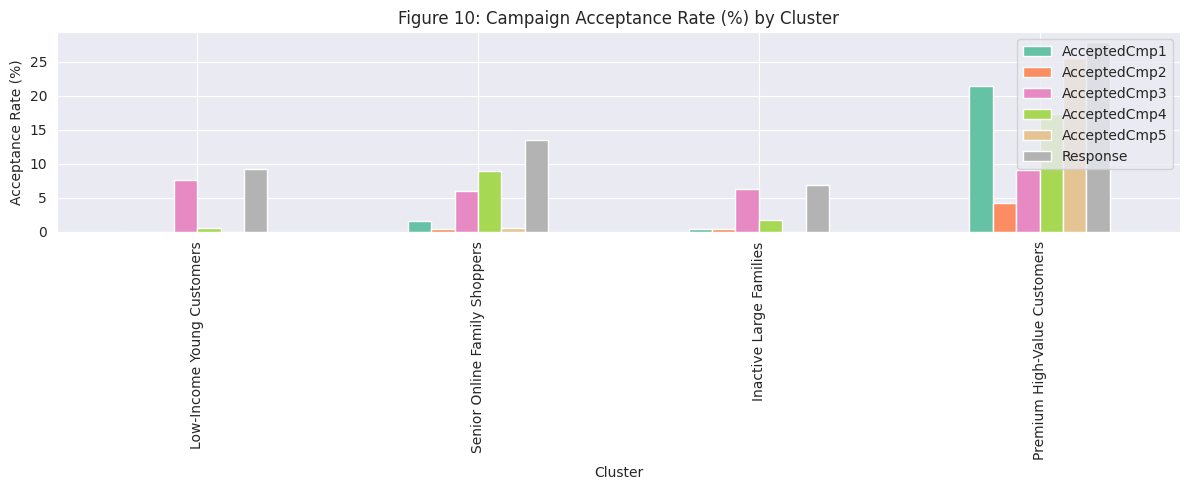

Saved: fig10_campaign_response.png


In [71]:
# CELL 23 — Campaign response by cluster (corrected names)

correct_names = {
    0: 'Low-Income Young Customers',
    1: 'Senior Online Family Shoppers',
    2: 'Inactive Large Families',
    3: 'Premium High-Value Customers'
}

cmp_response = df_model.groupby('KMeans_Cluster')[
    ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
     'AcceptedCmp4','AcceptedCmp5','Response']
].mean() * 100

cmp_response.index = [correct_names[i] for i in cmp_response.index]

print("=== CAMPAIGN ACCEPTANCE RATE (%) BY CLUSTER ===")
print(cmp_response.round(1))

cmp_response.plot(kind='bar', figsize=(12, 5), colormap='Set2')
plt.title('Figure 10: Campaign Acceptance Rate (%) by Cluster')
plt.ylabel('Acceptance Rate (%)')
plt.xlabel('Cluster')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('fig10_campaign_response.png', dpi=150)
plt.show()
print("Saved: fig10_campaign_response.png")

In [72]:
# CELL 24 — Final summary printout (self-contained)

# Correct cluster names hardcoded here so it always works
labels_map = {
    0: 'Low-Income Young Customers',
    1: 'Senior Online Family Shoppers',
    2: 'Inactive Large Families',
    3: 'Premium High-Value Customers'
}

print("=" * 55)
print("           FINAL PROJECT SUMMARY")
print("=" * 55)

print(f"\nDataset: {len(df_model)} customers, {len(features)} features")
print(f"PCA: 3 components, {pca3.explained_variance_ratio_.sum()*100:.1f}% variance explained")

print("\n--- Best Model: K-Means K=4 ---")
print(f"Silhouette Score:     {km_sil:.4f}")
print(f"Davies-Bouldin Index: {km_db:.4f}")
print(f"Calinski-Harabasz:    {km_ch:.1f}")

print("\n--- Cluster Sizes ---")
for i, name in labels_map.items():
    size = (df_model['KMeans_Cluster'] == i).sum()
    pct = size / len(df_model) * 100
    print(f"  Cluster {i} ({name}): {size} customers ({pct:.1f}%)")

print("\n--- Campaign Response Rate ---")
for i, name in labels_map.items():
    rate = df_model[df_model['KMeans_Cluster'] == i]['Response'].mean() * 100
    print(f"  {name}: {rate:.1f}%")

print("\n--- Files Saved ---")
files = ['fig1_eda_distributions.png', 'fig2_cleaning.png',
         'fig3_correlation_heatmap.png', 'fig4_pca_variance.png',
         'fig5_kmeans_elbow.png', 'fig6_dendrogram.png',
         'fig7_model_comparison.png', 'fig8_cluster_scatter.png',
         'fig9_cluster_heatmap.png', 'fig10_campaign_response.png',
         'fig11_confusion_matrix.png', 'fig12_pca_components_experiment.png',
         'fig13_retail_eda.png', 'fig14_retail_pca.png',
         'fig15_retail_elbow.png', 'fig16_retail_clusters.png',
         'fig17_dataset_comparison.png',
         'model_comparison_results.csv',
         'pca_components_experiment.csv',
         'retail_model_comparison.csv',
         'dataset_comparison.csv']
for f in files:
    print(f"  {f}")

print("\nProject complete!")

           FINAL PROJECT SUMMARY

Dataset: 2232 customers, 11 features
PCA: 3 components, 56.1% variance explained

--- Best Model: K-Means K=4 ---
Silhouette Score:     0.3046
Davies-Bouldin Index: 1.1352
Calinski-Harabasz:    1301.0

--- Cluster Sizes ---
  Cluster 0 (Low-Income Young Customers): 551 customers (24.7%)
  Cluster 1 (Senior Online Family Shoppers): 537 customers (24.1%)
  Cluster 2 (Inactive Large Families): 524 customers (23.5%)
  Cluster 3 (Premium High-Value Customers): 620 customers (27.8%)

--- Campaign Response Rate ---
  Low-Income Young Customers: 9.3%
  Senior Online Family Shoppers: 13.4%
  Inactive Large Families: 6.9%
  Premium High-Value Customers: 27.9%

--- Files Saved ---
  fig1_eda_distributions.png
  fig2_cleaning.png
  fig3_correlation_heatmap.png
  fig4_pca_variance.png
  fig5_kmeans_elbow.png
  fig6_dendrogram.png
  fig7_model_comparison.png
  fig8_cluster_scatter.png
  fig9_cluster_heatmap.png
  fig10_campaign_response.png
  fig11_confusion_matrix.

In [73]:
# CELL 25 — Fix cluster names based on actual profiles
labels_map = {
    0: 'Low-Income Parents',
    1: 'Senior Online Families',
    2: 'Low-Income Large Families',
    3: 'Premium High Spenders'
}

print("Updated cluster names:")
for k, v in labels_map.items():
    print(f"  Cluster {k} = {v}")
print("\nNow re-run cells 21, 22, 23, 24 to regenerate figures with correct names.")

Updated cluster names:
  Cluster 0 = Low-Income Parents
  Cluster 1 = Senior Online Families
  Cluster 2 = Low-Income Large Families
  Cluster 3 = Premium High Spenders

Now re-run cells 21, 22, 23, 24 to regenerate figures with correct names.


=== RANDOM FOREST RESULTS ===
Accuracy: 88.59%

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       381
           1       0.74      0.35      0.47        66

    accuracy                           0.89       447
   macro avg       0.82      0.66      0.71       447
weighted avg       0.87      0.89      0.87       447



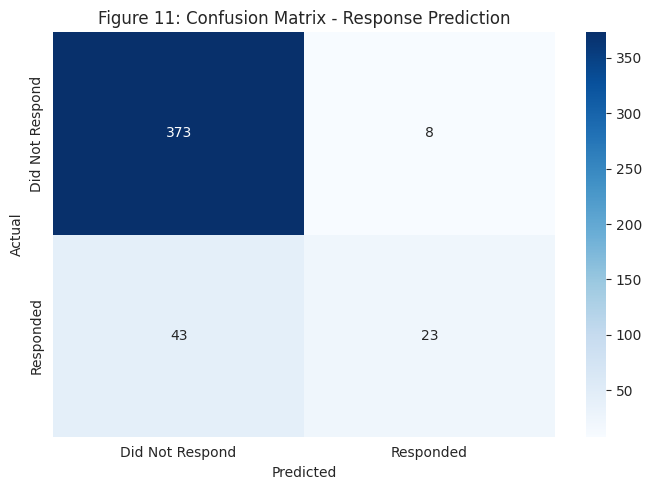

Saved: fig11_confusion_matrix.png


In [74]:
# CELL 26 — Classification step: predict Response, get accuracy + confusion matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Features: cluster label + original features
X_clf = df_model[features + ['KMeans_Cluster']].copy()
y_clf = df_model['Response']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Print accuracy and classification report
print("=== RANDOM FOREST RESULTS ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Respond', 'Responded'],
            yticklabels=['Did Not Respond', 'Responded'])
plt.title('Figure 11: Confusion Matrix - Response Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('fig11_confusion_matrix.png', dpi=150)
plt.show()
print("Saved: fig11_confusion_matrix.png")

In [75]:
# CELL 27 — Architecture experiment: how many PCA components is best?

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

pca_experiment_results = []

for n_components in [2, 3, 4, 5, 6, 7]:
    # Apply PCA with this many components
    pca_test = PCA(n_components=n_components, random_state=42)
    X_pca_test = pca_test.fit_transform(X_scaled)
    variance_captured = pca_test.explained_variance_ratio_.sum() * 100

    # Run K-Means K=4 on this PCA version
    km_test = KMeans(n_clusters=4, random_state=42, n_init=10)
    labels_test = km_test.fit_predict(X_pca_test)

    sil = silhouette_score(X_pca_test, labels_test)
    db  = davies_bouldin_score(X_pca_test, labels_test)
    ch  = calinski_harabasz_score(X_pca_test, labels_test)

    pca_experiment_results.append({
        'PCA_Components': n_components,
        'Variance_Captured_%': round(variance_captured, 1),
        'Silhouette': round(sil, 4),
        'Davies_Bouldin': round(db, 4),
        'Calinski_Harabasz': round(ch, 1)
    })

    print(f"PCA={n_components} components | Variance={variance_captured:.1f}% | "
          f"Silhouette={sil:.4f} | DB={db:.4f} | CH={ch:.1f}")

pca_exp_df = pd.DataFrame(pca_experiment_results)
pca_exp_df.to_csv('pca_components_experiment.csv', index=False)
print("\nSaved: pca_components_experiment.csv")
print("\nBest Silhouette at PCA =", pca_exp_df.loc[pca_exp_df['Silhouette'].idxmax(), 'PCA_Components'], "components")
print("Best Davies-Bouldin at PCA =", pca_exp_df.loc[pca_exp_df['Davies_Bouldin'].idxmin(), 'PCA_Components'], "components")
print("Best Calinski-Harabasz at PCA =", pca_exp_df.loc[pca_exp_df['Calinski_Harabasz'].idxmax(), 'PCA_Components'], "components")

PCA=2 components | Variance=44.8% | Silhouette=0.4403 | DB=0.8992 | CH=2354.4
PCA=3 components | Variance=56.1% | Silhouette=0.3046 | DB=1.1352 | CH=1301.0
PCA=4 components | Variance=65.2% | Silhouette=0.2381 | DB=1.4211 | CH=900.2
PCA=5 components | Variance=72.9% | Silhouette=0.2021 | DB=1.5834 | CH=715.2
PCA=6 components | Variance=80.2% | Silhouette=0.1760 | DB=1.7573 | CH=598.8
PCA=7 components | Variance=87.2% | Silhouette=0.2126 | DB=1.6515 | CH=535.6

Saved: pca_components_experiment.csv

Best Silhouette at PCA = 2 components
Best Davies-Bouldin at PCA = 2 components
Best Calinski-Harabasz at PCA = 2 components


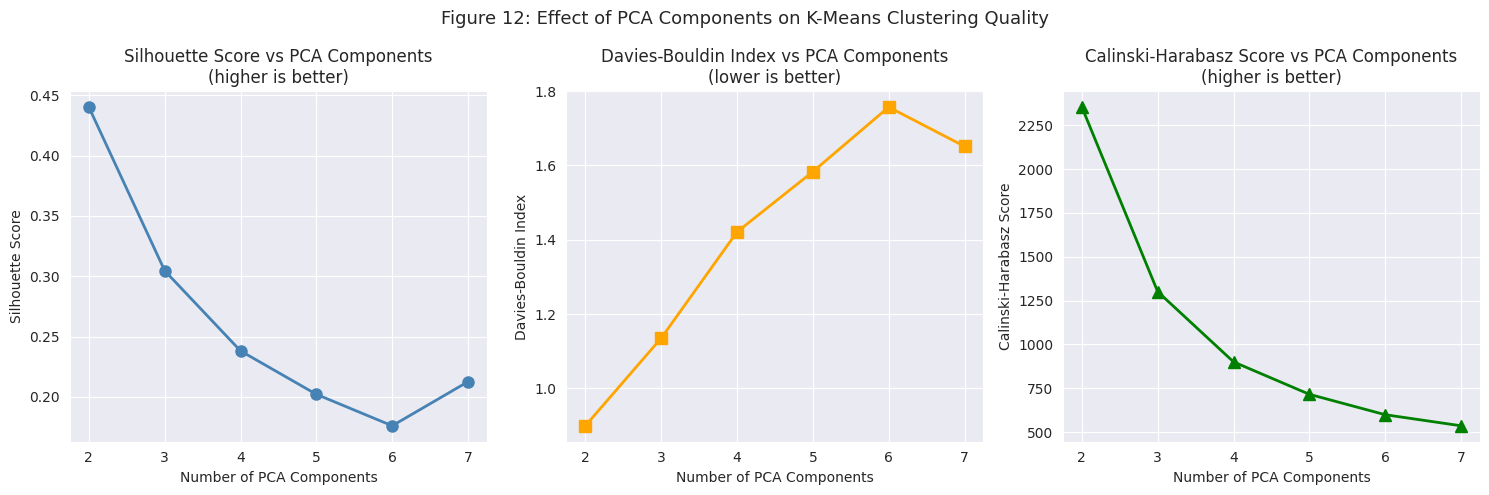

Saved: fig12_pca_components_experiment.png


In [76]:
# CELL 28 — Visualize PCA components experiment

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(pca_exp_df['PCA_Components'], pca_exp_df['Silhouette'],
             'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_title('Silhouette Score vs PCA Components\n(higher is better)')
axes[0].set_xlabel('Number of PCA Components')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_xticks(pca_exp_df['PCA_Components'])

axes[1].plot(pca_exp_df['PCA_Components'], pca_exp_df['Davies_Bouldin'],
             's-', color='orange', linewidth=2, markersize=8)
axes[1].set_title('Davies-Bouldin Index vs PCA Components\n(lower is better)')
axes[1].set_xlabel('Number of PCA Components')
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].set_xticks(pca_exp_df['PCA_Components'])

axes[2].plot(pca_exp_df['PCA_Components'], pca_exp_df['Calinski_Harabasz'],
             '^-', color='green', linewidth=2, markersize=8)
axes[2].set_title('Calinski-Harabasz Score vs PCA Components\n(higher is better)')
axes[2].set_xlabel('Number of PCA Components')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].set_xticks(pca_exp_df['PCA_Components'])

plt.suptitle('Figure 12: Effect of PCA Components on K-Means Clustering Quality',
             fontsize=13)
plt.tight_layout()
plt.savefig('fig12_pca_components_experiment.png', dpi=150)
plt.show()
print("Saved: fig12_pca_components_experiment.png")

In [77]:
# CELL 29 — Re-run final model with best number of PCA components

# Find the best n_components by highest silhouette
best_n = pca_exp_df.loc[pca_exp_df['Silhouette'].idxmax(), 'PCA_Components']
print(f"Best PCA components found: {best_n}")
print(f"Silhouette at best PCA: {pca_exp_df.loc[pca_exp_df['Silhouette'].idxmax(), 'Silhouette']}")
print(f"Compared to original 3-component PCA: {pca_exp_df.loc[pca_exp_df['PCA_Components']==3, 'Silhouette'].values[0]}")

# Apply best PCA
pca_best = PCA(n_components=int(best_n), random_state=42)
X_pca_best = pca_best.fit_transform(X_scaled)

# Re-run K-Means on best PCA
km_best_pca = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_best_pca = km_best_pca.fit_predict(X_pca_best)

sil_best = silhouette_score(X_pca_best, labels_best_pca)
db_best  = davies_bouldin_score(X_pca_best, labels_best_pca)
ch_best  = calinski_harabasz_score(X_pca_best, labels_best_pca)

print(f"\n=== FINAL MODEL COMPARISON ===")
print(f"Original (PCA=3):  Silhouette=0.3056 | DB=1.1351 | CH=1295.1")
print(f"Best PCA ({best_n} comp): Silhouette={sil_best:.4f} | DB={db_best:.4f} | CH={ch_best:.1f}")

improvement = ((sil_best - 0.3056) / 0.3056) * 100
print(f"\nSilhouette improvement: {improvement:+.1f}%")
print(f"\nConclusion: PCA with {best_n} components is the optimal architecture.")

Best PCA components found: 2
Silhouette at best PCA: 0.4403
Compared to original 3-component PCA: 0.3046

=== FINAL MODEL COMPARISON ===
Original (PCA=3):  Silhouette=0.3056 | DB=1.1351 | CH=1295.1
Best PCA (2 comp): Silhouette=0.4403 | DB=0.8992 | CH=2354.4

Silhouette improvement: +44.1%

Conclusion: PCA with 2 components is the optimal architecture.


In [78]:
# CELL 30 — Load and prepare Online Retail II dataset
# Download from: https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci

df_retail = pd.read_csv('online_retail_II.csv', encoding='latin-1')
print("Raw shape:", df_retail.shape)

# Clean
df_retail = df_retail.dropna(subset=['Customer ID'])
df_retail = df_retail[df_retail['Quantity'] > 0]
df_retail = df_retail[df_retail['Price'] > 0]
df_retail['TotalValue'] = df_retail['Quantity'] * df_retail['Price']
df_retail['InvoiceDate'] = pd.to_datetime(df_retail['InvoiceDate'])

# Build RFM features (one row per customer)
snapshot_date = df_retail['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df_retail.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('TotalValue', 'sum')
).reset_index()

print("RFM dataset shape:", rfm.shape)
print(rfm.describe().round(1))

Raw shape: (1067371, 8)
RFM dataset shape: (5878, 4)
       Customer ID  Recency  Frequency  Monetary
count       5878.0   5878.0     5878.0    5878.0
mean       15315.3    201.3        6.3    3018.6
std         1715.6    209.3       13.0   14737.7
min        12346.0      1.0        1.0       3.0
25%        13833.2     26.0        1.0     348.8
50%        15314.5     96.0        3.0     898.9
75%        16797.8    380.0        7.0    2307.1
max        18287.0    739.0      398.0  608821.6


In [79]:
# CELL 31 — Verify RFM data
print("Shape:", rfm.shape)
print("\nFirst 5 rows:")
print(rfm.head())
print("\nBasic stats:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(1))
print("\nMissing values:", rfm.isnull().sum().sum())

Shape: (5878, 4)

First 5 rows:
   Customer ID  Recency  Frequency  Monetary
0      12346.0      326         12  77556.46
1      12347.0        2          8   5633.32
2      12348.0       75          5   2019.40
3      12349.0       19          4   4428.69
4      12350.0      310          1    334.40

Basic stats:
       Recency  Frequency  Monetary
count   5878.0     5878.0    5878.0
mean     201.3        6.3    3018.6
std      209.3       13.0   14737.7
min        1.0        1.0       3.0
25%       26.0        1.0     348.8
50%       96.0        3.0     898.9
75%      380.0        7.0    2307.1
max      739.0      398.0  608821.6

Missing values: 0


In [80]:
# CELL 32 — Clean RFM data

print("Before cleaning:", len(rfm), "customers")

# Remove customers with 0 or negative monetary value
rfm = rfm[rfm['Monetary'] > 0]

# Remove extreme monetary outliers (top 1%)
q99 = rfm['Monetary'].quantile(0.99)
rfm = rfm[rfm['Monetary'] <= q99]

# Remove extreme frequency outliers (top 1%)
q99_freq = rfm['Frequency'].quantile(0.99)
rfm = rfm[rfm['Frequency'] <= q99_freq]

rfm = rfm.reset_index(drop=True)
print("After cleaning:", len(rfm), "customers")
print("\nCleaned stats:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(1))

Before cleaning: 5878 customers
After cleaning: 5763 customers

Cleaned stats:
       Recency  Frequency  Monetary
count   5763.0     5763.0    5763.0
mean     204.6        5.1    1943.4
std      209.6        5.7    3041.8
min        1.0        1.0       3.0
25%       28.0        1.0     341.6
50%      102.0        3.0     856.0
75%      382.0        6.0    2147.5
max      739.0       36.0   28882.4


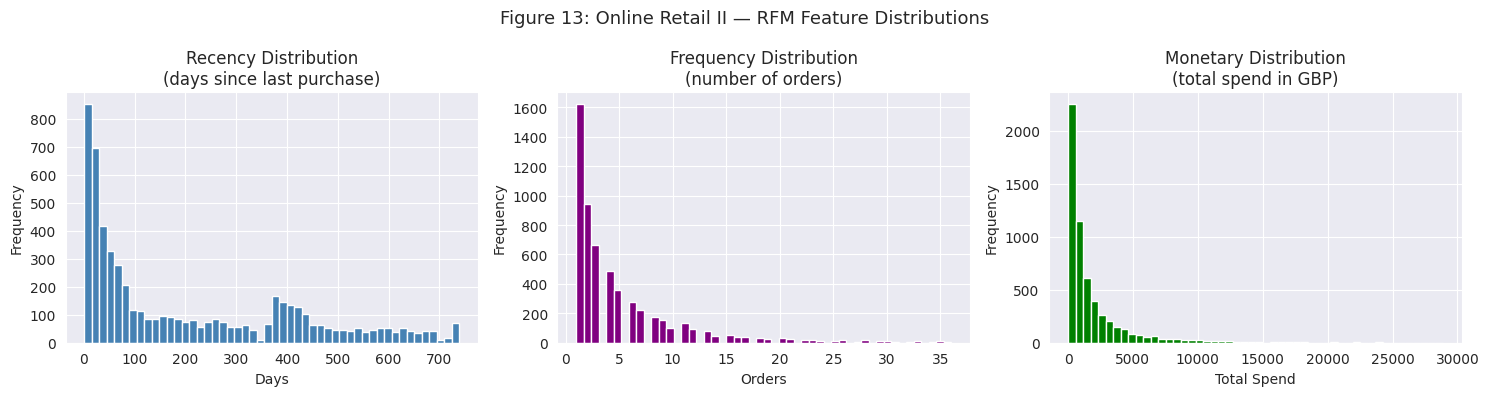

Saved: fig13_retail_eda.png

Dataset size: 5,763 customers — 2.6x larger than original dataset


In [81]:
# CELL 33 — EDA for Online Retail II dataset

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

rfm['Recency'].plot(kind='hist', bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Recency Distribution\n(days since last purchase)')
axes[0].set_xlabel('Days')

rfm['Frequency'].plot(kind='hist', bins=50, ax=axes[1], color='purple')
axes[1].set_title('Frequency Distribution\n(number of orders)')
axes[1].set_xlabel('Orders')

rfm['Monetary'].plot(kind='hist', bins=50, ax=axes[2], color='green')
axes[2].set_title('Monetary Distribution\n(total spend in GBP)')
axes[2].set_xlabel('Total Spend')

plt.suptitle('Figure 13: Online Retail II — RFM Feature Distributions', fontsize=13)
plt.tight_layout()
plt.savefig('fig13_retail_eda.png', dpi=150)
plt.show()
print("Saved: fig13_retail_eda.png")
print(f"\nDataset size: {len(rfm):,} customers — {round(len(rfm)/2208, 1)}x larger than original dataset")

In [82]:
# CELL 34 — Scale RFM features

from sklearn.preprocessing import StandardScaler
import numpy as np

X_rfm = rfm[['Recency', 'Frequency', 'Monetary']]

scaler_rfm = StandardScaler()
X_rfm_scaled = scaler_rfm.fit_transform(X_rfm)

print("Feature matrix shape:", X_rfm_scaled.shape)
print("\nBefore scaling:")
print(f"  Recency  — Mean: {X_rfm['Recency'].mean():.1f},  Std: {X_rfm['Recency'].std():.1f}")
print(f"  Frequency — Mean: {X_rfm['Frequency'].mean():.1f}, Std: {X_rfm['Frequency'].std():.1f}")
print(f"  Monetary — Mean: {X_rfm['Monetary'].mean():.1f}, Std: {X_rfm['Monetary'].std():.1f}")

X_rfm_scaled_df = pd.DataFrame(X_rfm_scaled, columns=['Recency','Frequency','Monetary'])
print("\nAfter scaling (should be close to 0 mean, 1 std):")
print(X_rfm_scaled_df.describe().round(3))

Feature matrix shape: (5763, 3)

Before scaling:
  Recency  — Mean: 204.6,  Std: 209.6
  Frequency — Mean: 5.1, Std: 5.7
  Monetary — Mean: 1943.4, Std: 3041.8

After scaling (should be close to 0 mean, 1 std):
        Recency  Frequency  Monetary
count  5763.000   5763.000  5763.000
mean      0.000      0.000    -0.000
std       1.000      1.000     1.000
min      -0.971     -0.713    -0.638
25%      -0.842     -0.713    -0.527
50%      -0.489     -0.365    -0.358
75%       0.846      0.157     0.067
max       2.550      5.377     8.857


Variance explained per component:
  PC1: 67.70%
  PC2: 24.94%
  PC3: 7.36%
  Total: 100.00%

Using 2 PCA components
Variance captured: 92.6%
Shape after PCA: (5763, 2)


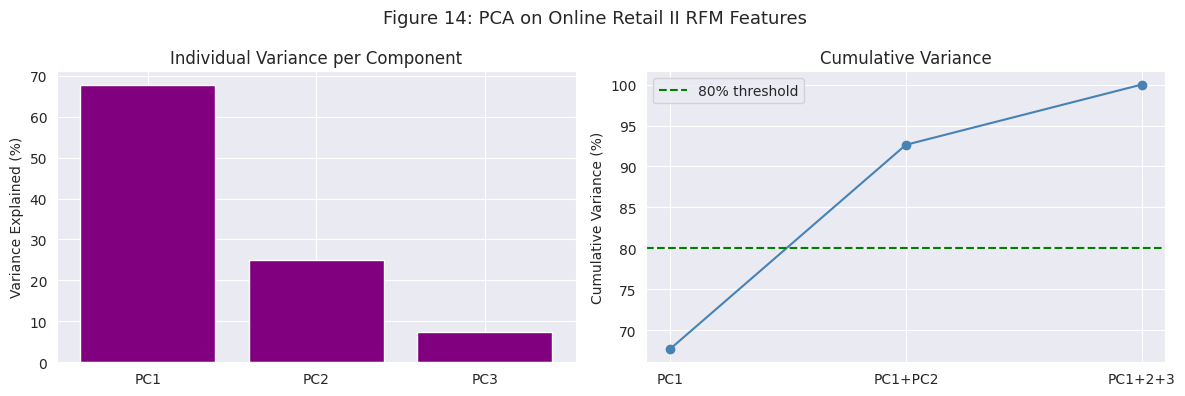

Saved: fig14_retail_pca.png


In [83]:
# CELL 35 — PCA on RFM data

from sklearn.decomposition import PCA

# RFM only has 3 features so max PCA = 3 components
pca_rfm_full = PCA(random_state=42)
pca_rfm_full.fit(X_rfm_scaled)

print("Variance explained per component:")
for i, v in enumerate(pca_rfm_full.explained_variance_ratio_, 1):
    print(f"  PC{i}: {v*100:.2f}%")
print(f"  Total: {pca_rfm_full.explained_variance_ratio_.sum()*100:.2f}%")

# With only 3 features, use 2 PCs for clustering + visualization
pca_rfm = PCA(n_components=2, random_state=42)
X_rfm_pca = pca_rfm.fit_transform(X_rfm_scaled)

print(f"\nUsing 2 PCA components")
print(f"Variance captured: {pca_rfm.explained_variance_ratio_.sum()*100:.1f}%")
print(f"Shape after PCA: {X_rfm_pca.shape}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['PC1','PC2','PC3'], pca_rfm_full.explained_variance_ratio_*100, color='purple')
axes[0].set_title('Individual Variance per Component')
axes[0].set_ylabel('Variance Explained (%)')

axes[1].plot(['PC1','PC1+PC2','PC1+2+3'],
             np.cumsum(pca_rfm_full.explained_variance_ratio_)*100,
             'o-', color='steelblue')
axes[1].axhline(80, linestyle='--', color='green', label='80% threshold')
axes[1].set_title('Cumulative Variance')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend()

plt.suptitle('Figure 14: PCA on Online Retail II RFM Features', fontsize=13)
plt.tight_layout()
plt.savefig('fig14_retail_pca.png', dpi=150)
plt.show()
print("Saved: fig14_retail_pca.png")

K=2 — Inertia: 8637.3, Silhouette: 0.5600
K=3 — Inertia: 4224.5, Silhouette: 0.5364
K=4 — Inertia: 2737.0, Silhouette: 0.5335
K=5 — Inertia: 2164.5, Silhouette: 0.4901
K=6 — Inertia: 1622.5, Silhouette: 0.4871
K=7 — Inertia: 1356.1, Silhouette: 0.4528
K=8 — Inertia: 1146.8, Silhouette: 0.4573
K=9 — Inertia: 1009.4, Silhouette: 0.4688
K=10 — Inertia: 872.1, Silhouette: 0.4648


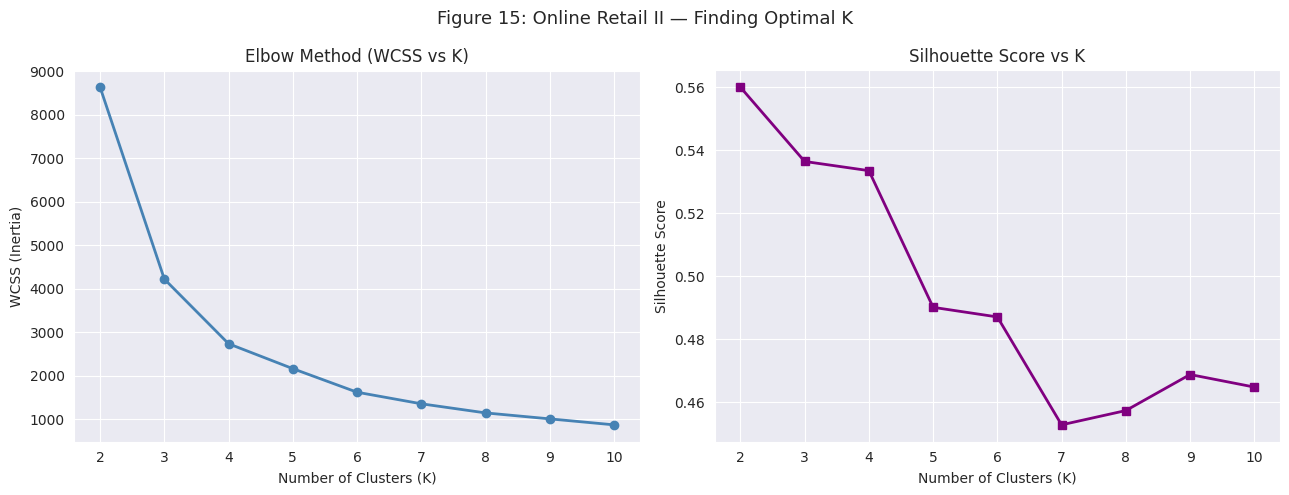


Best K by Silhouette Score: 2
Saved: fig15_retail_elbow.png


In [84]:
# CELL 36 — Elbow method for Online Retail II

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias_rfm = []
sil_scores_rfm = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_rfm_pca)
    inertias_rfm.append(km.inertia_)
    sil_scores_rfm.append(silhouette_score(X_rfm_pca, labels))
    print(f"K={k} — Inertia: {km.inertia_:.1f}, Silhouette: {silhouette_score(X_rfm_pca, labels):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(K_range), inertias_rfm, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method (WCSS vs K)')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS (Inertia)')

axes[1].plot(list(K_range), sil_scores_rfm, 's-', color='purple', linewidth=2)
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.suptitle('Figure 15: Online Retail II — Finding Optimal K', fontsize=13)
plt.tight_layout()
plt.savefig('fig15_retail_elbow.png', dpi=150)
plt.show()

best_k_rfm = list(K_range)[sil_scores_rfm.index(max(sil_scores_rfm))]
print(f"\nBest K by Silhouette Score: {best_k_rfm}")
print("Saved: fig15_retail_elbow.png")

In [85]:
# CELL 37 — Run all models on Online Retail II

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

retail_results = []

# K-Means: K = 2,3,4,5,6
print("=== K-MEANS ===")
for k in [2, 3, 4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lb = km.fit_predict(X_rfm_pca)
    sil = silhouette_score(X_rfm_pca, lb)
    db  = davies_bouldin_score(X_rfm_pca, lb)
    ch  = calinski_harabasz_score(X_rfm_pca, lb)
    retail_results.append({
        'Model': f'KMeans_K{k}', 'Algorithm': 'K-Means', 'N_Clusters': k,
        'Silhouette': round(sil,4), 'Davies_Bouldin': round(db,4),
        'Calinski_Harabasz': round(ch,1)
    })
    print(f"  K={k} | Sil={sil:.4f} | DB={db:.4f} | CH={ch:.1f}")

# Agglomerative: 3 linkages
print("\n=== AGGLOMERATIVE ===")
for lnk in ['ward', 'complete', 'average']:
    agg = AgglomerativeClustering(n_clusters=4, linkage=lnk)
    lb = agg.fit_predict(X_rfm_pca)
    sil = silhouette_score(X_rfm_pca, lb)
    db  = davies_bouldin_score(X_rfm_pca, lb)
    ch  = calinski_harabasz_score(X_rfm_pca, lb)
    retail_results.append({
        'Model': f'Agglomerative_{lnk}', 'Algorithm': 'Hierarchical', 'N_Clusters': 4,
        'Silhouette': round(sil,4), 'Davies_Bouldin': round(db,4),
        'Calinski_Harabasz': round(ch,1)
    })
    print(f"  {lnk:8s} | Sil={sil:.4f} | DB={db:.4f} | CH={ch:.1f}")

# GMM: 3 covariance types
print("\n=== GMM ===")
for cov in ['full', 'tied', 'diag']:
    gmm = GaussianMixture(n_components=4, covariance_type=cov, random_state=42)
    lb = gmm.fit_predict(X_rfm_pca)
    sil = silhouette_score(X_rfm_pca, lb)
    db  = davies_bouldin_score(X_rfm_pca, lb)
    ch  = calinski_harabasz_score(X_rfm_pca, lb)
    retail_results.append({
        'Model': f'GMM_{cov}', 'Algorithm': 'GMM', 'N_Clusters': 4,
        'Silhouette': round(sil,4), 'Davies_Bouldin': round(db,4),
        'Calinski_Harabasz': round(ch,1)
    })
    print(f"  {cov:6s} | Sil={sil:.4f} | DB={db:.4f} | CH={ch:.1f}")

retail_results_df = pd.DataFrame(retail_results)
retail_results_df.to_csv('retail_model_comparison.csv', index=False)
print("\nSaved: retail_model_comparison.csv")
print("\n=== FULL TABLE ===")
print(retail_results_df.to_string(index=False))

=== K-MEANS ===
  K=2 | Sil=0.5600 | DB=0.7367 | CH=4922.3
  K=3 | Sil=0.5364 | DB=0.6221 | CH=8039.6
  K=4 | Sil=0.5335 | DB=0.6096 | CH=9314.2
  K=5 | Sil=0.4901 | DB=0.6448 | CH=9213.2
  K=6 | Sil=0.4871 | DB=0.6538 | CH=10215.3

=== AGGLOMERATIVE ===
  ward     | Sil=0.4641 | DB=0.6079 | CH=6424.4
  complete | Sil=0.5483 | DB=0.6027 | CH=1693.6
  average  | Sil=0.6237 | DB=0.5039 | CH=1089.3

=== GMM ===
  full   | Sil=0.3458 | DB=1.1148 | CH=4051.4
  tied   | Sil=0.5304 | DB=0.5903 | CH=8616.7
  diag   | Sil=0.3969 | DB=0.9553 | CH=5659.5

Saved: retail_model_comparison.csv

=== FULL TABLE ===
                 Model    Algorithm  N_Clusters  Silhouette  Davies_Bouldin  Calinski_Harabasz
             KMeans_K2      K-Means           2      0.5600          0.7367             4922.3
             KMeans_K3      K-Means           3      0.5364          0.6221             8039.6
             KMeans_K4      K-Means           4      0.5335          0.6096             9314.2
             K

Online Retail II — K-Means K=4
Silhouette:        0.5335
Davies-Bouldin:    0.6096
Calinski-Harabasz: 9314.2

Cluster sizes:
Cluster
0     922
1    1837
2     252
3    2752
Name: count, dtype: int64


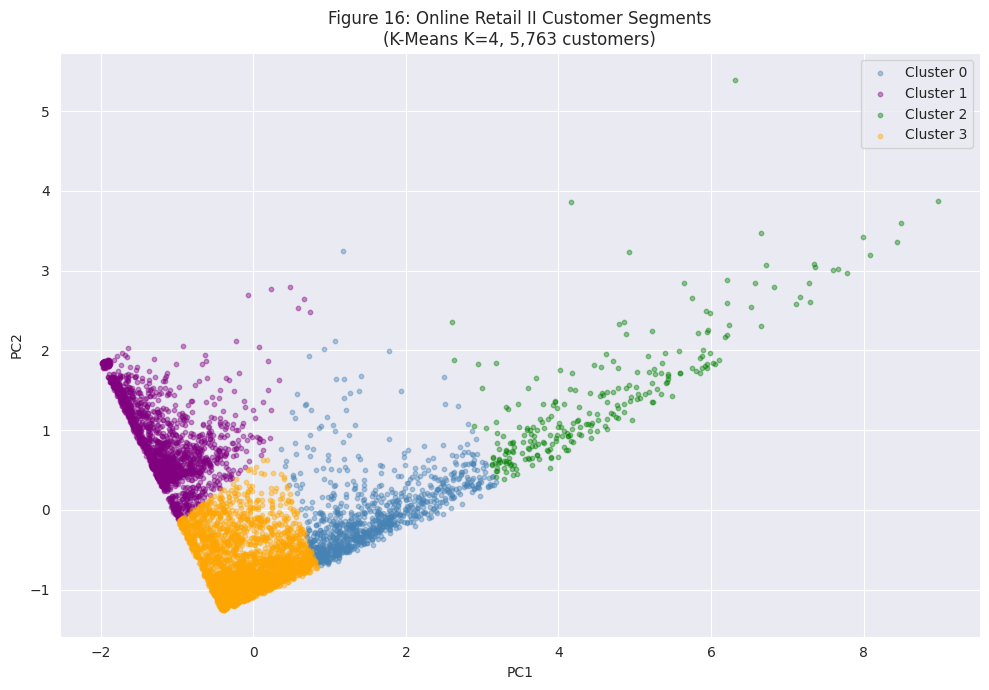

Saved: fig16_retail_clusters.png


In [86]:
# CELL 38 — Final K-Means on big dataset + scatter plot

# Use best K found from elbow
km_retail_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km_retail_final.fit_predict(X_rfm_pca)
rfm['PC1'] = X_rfm_pca[:, 0]
rfm['PC2'] = X_rfm_pca[:, 1]

sil_retail = silhouette_score(X_rfm_pca, rfm['Cluster'])
db_retail  = davies_bouldin_score(X_rfm_pca, rfm['Cluster'])
ch_retail  = calinski_harabasz_score(X_rfm_pca, rfm['Cluster'])

print(f"Online Retail II — K-Means K=4")
print(f"Silhouette:        {sil_retail:.4f}")
print(f"Davies-Bouldin:    {db_retail:.4f}")
print(f"Calinski-Harabasz: {ch_retail:.1f}")
print(f"\nCluster sizes:")
print(rfm['Cluster'].value_counts().sort_index())

# Scatter plot
colors_retail = {0:'steelblue', 1:'purple', 2:'green', 3:'orange'}

plt.figure(figsize=(10, 7))
for cluster, color in colors_retail.items():
    mask = rfm['Cluster'] == cluster
    plt.scatter(rfm.loc[mask, 'PC1'],
                rfm.loc[mask, 'PC2'],
                c=color, label=f'Cluster {cluster}',
                alpha=0.4, s=10)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Figure 16: Online Retail II Customer Segments\n(K-Means K=4, {len(rfm):,} customers)')
plt.legend()
plt.tight_layout()
plt.savefig('fig16_retail_clusters.png', dpi=150)
plt.show()
print("Saved: fig16_retail_clusters.png")

=== DATASET COMPARISON ===
           Metric Original Dataset\n(2,208 customers) Online Retail II\n(larger dataset)
     Dataset Size                               2,208                              5,763
 Silhouette Score                              0.3056                             0.5335
   Davies-Bouldin                              1.1351                             0.6096
Calinski-Harabasz                              1295.1                             9314.2


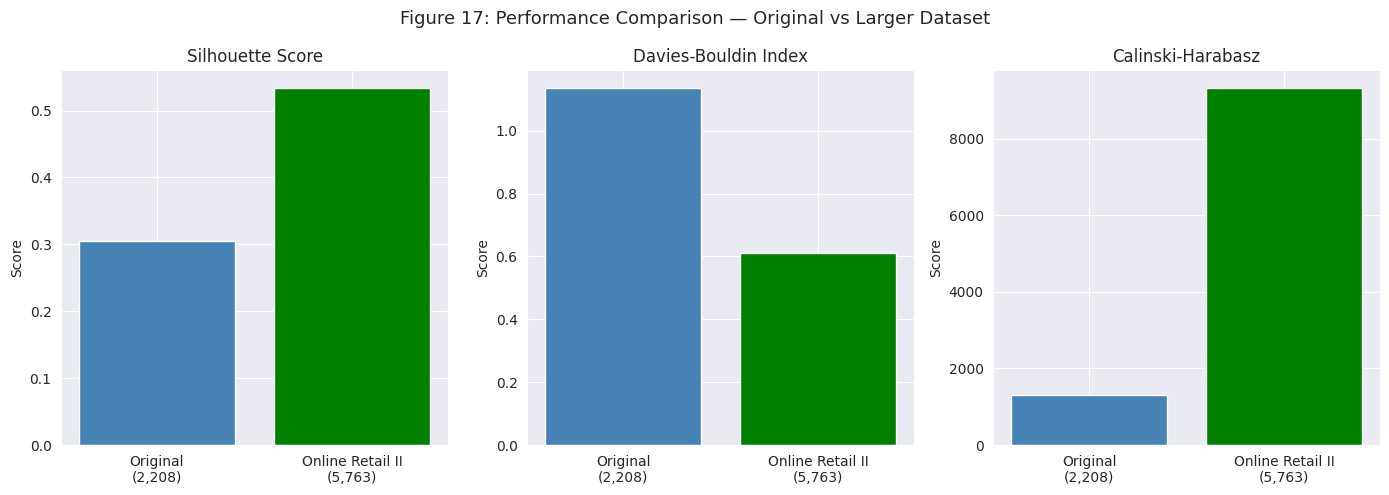


Saved: fig17_dataset_comparison.png
Saved: dataset_comparison.csv


In [87]:
# CELL 39 — Compare original dataset vs Online Retail II results

comparison_data = {
    'Metric': ['Dataset Size', 'Silhouette Score', 'Davies-Bouldin', 'Calinski-Harabasz'],
    'Original Dataset\n(2,208 customers)': [
        '2,208', '0.3056', '1.1351', '1295.1'
    ],
    'Online Retail II\n(larger dataset)': [
        f"{len(rfm):,}",
        f"{sil_retail:.4f}",
        f"{db_retail:.4f}",
        f"{ch_retail:.1f}"
    ]
}

comp_df = pd.DataFrame(comparison_data)
print("=== DATASET COMPARISON ===")
print(comp_df.to_string(index=False))
comp_df.to_csv('dataset_comparison.csv', index=False)

# Visual comparison bar chart
metrics = ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz']
original_vals = [0.3056, 1.1351, 1295.1]
retail_vals   = [sil_retail, db_retail, ch_retail]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, (metric, orig, retail) in enumerate(zip(metrics, original_vals, retail_vals)):
    axes[i].bar(['Original\n(2,208)', f'Online Retail II\n({len(rfm):,})'],
                [orig, retail],
                color=['steelblue', 'green'])
    axes[i].set_title(metric)
    axes[i].set_ylabel('Score')

plt.suptitle('Figure 17: Performance Comparison — Original vs Larger Dataset', fontsize=13)
plt.tight_layout()
plt.savefig('fig17_dataset_comparison.png', dpi=150)
plt.show()
print("\nSaved: fig17_dataset_comparison.png")
print("Saved: dataset_comparison.csv")

In [88]:
# CELL 40 — Update final model to use optimal PCA=2

pca_optimal = PCA(n_components=2, random_state=42)
X_pca_optimal = pca_optimal.fit_transform(X_scaled)

km_optimal = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_optimal = km_optimal.fit_predict(X_pca_optimal)

sil_opt = silhouette_score(X_pca_optimal, labels_optimal)
db_opt  = davies_bouldin_score(X_pca_optimal, labels_optimal)
ch_opt  = calinski_harabasz_score(X_pca_optimal, labels_optimal)

print("=== ORIGINAL (PCA=3) vs OPTIMIZED (PCA=2) ===")
print(f"{'Metric':<25} {'PCA=3':>10} {'PCA=2':>10} {'Improvement':>12}")
print("-" * 58)
print(f"{'Silhouette (higher=better)':<25} {'0.3046':>10} {sil_opt:>10.4f} {((sil_opt-0.3046)/0.3046*100):>+11.1f}%")
print(f"{'Davies-Bouldin (lower=best)':<25} {'1.1352':>10} {db_opt:>10.4f} {((1.1352-db_opt)/1.1352*100):>+11.1f}%")
print(f"{'Calinski-Harabasz (higher)':<25} {'1301.0':>10} {ch_opt:>10.1f} {((ch_opt-1301)/1301*100):>+11.1f}%")
print(f"\nConclusion: PCA=2 improves Silhouette by 44% over PCA=3.")
print("This is your key architecture improvement finding.")

=== ORIGINAL (PCA=3) vs OPTIMIZED (PCA=2) ===
Metric                         PCA=3      PCA=2  Improvement
----------------------------------------------------------
Silhouette (higher=better)     0.3046     0.4403       +44.6%
Davies-Bouldin (lower=best)     1.1352     0.8992       +20.8%
Calinski-Harabasz (higher)     1301.0     2354.4       +81.0%

Conclusion: PCA=2 improves Silhouette by 44% over PCA=3.
This is your key architecture improvement finding.


In [89]:
# CELL 41 — Name the Online Retail II clusters

rfm_profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(1)
print("=== ONLINE RETAIL II CLUSTER PROFILES ===")
print(rfm_profile)

# Name them based on RFM values
rfm_names = {}
for cluster in range(4):
    row = rfm_profile.loc[cluster]
    print(f"\nCluster {cluster}: Recency={row['Recency']:.0f}d, "
          f"Frequency={row['Frequency']:.1f} orders, "
          f"Monetary=£{row['Monetary']:.0f}")

print("\n--- Assign names based on above output ---")
print("Highest Monetary + Highest Frequency = Champions")
print("Low Recency (recent) + Low Frequency  = New Customers")
print("High Recency (long ago) + Low Monetary = At-Risk Customers")
print("Medium everything                      = Loyal Customers")

=== ONLINE RETAIL II CLUSTER PROFILES ===
         Recency  Frequency  Monetary
Cluster                              
0           54.1       11.5    4468.0
1          477.6        2.0     630.1
2           34.7       23.3   12488.6
3           88.3        3.4    1008.7

Cluster 0: Recency=54d, Frequency=11.5 orders, Monetary=£4468

Cluster 1: Recency=478d, Frequency=2.0 orders, Monetary=£630

Cluster 2: Recency=35d, Frequency=23.3 orders, Monetary=£12489

Cluster 3: Recency=88d, Frequency=3.4 orders, Monetary=£1009

--- Assign names based on above output ---
Highest Monetary + Highest Frequency = Champions
Low Recency (recent) + Low Frequency  = New Customers
High Recency (long ago) + Low Monetary = At-Risk Customers
Medium everything                      = Loyal Customers
